# Geospatial Analysis of California and San Diego Traffic Sensor Networks
This notebook provides a comprehensive geospatial analysis of the Caltrans Performance Measurement System (PeMS) sensor networks.

### Analytical Scope:
1. **Macro Context (State of California)**:
   - Map all **8,600 sensors** across California (`data/metadata.csv`) covering 9 Caltrans Districts.
   - Highlight the **San Diego study subset in red (716 sensors / 8.3%)** against all remaining **California sensors in blue (7,884 sensors / 91.7%)**.
2. **Micro Analysis (San Diego County Study Area)**:
   - Map all 716 loop detector stations based on Latitude and Longitude with accurate aspect ratio.
   - Distinguish and trace all **13 freeway corridors** (`I5`, `I15`, `I805`, `I8`, `SR78`, `SR94`, `SR52`, `SR125`, `SR163`, `SR56`, `I905`, `SR54`, `SR11`).
   - Feature a cartographic **compass rose** indicating cardinal directions (**N / S / E / W**).
   - Analyze travel directionality (`N`, `S`, `E`, `W`) and compare North-South arterial spines vs East-West connectors.
   - Map highway infrastructure capacity (`Lanes`) and identify bottleneck convergence points.
   - Map 2019 geospatial traffic flow intensity across the county.
   - Analyze spatial graph proximity and sensor spacing for Spatiotemporal Graph Neural Networks (STGNN, DCRNN, Graph WaveNet).


## 1. Macro Perspective: California Statewide Highway Sensor Network (8,600 Sensors)
We first examine the complete statewide Caltrans PeMS inventory (`data/metadata.csv`).
This dataset contains **8,600 sensor stations** across 34 counties and 9 Caltrans Districts, spanning from the Oregon border down to Mexico.


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon, Circle
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")

# Reusable cartographic compass rose function
def add_compass(ax, loc=(0.07, 0.14), size=0.085, text_color="#212121", ring_alpha=0.6):
    """
    Draws a cartographic compass rose with cardinal directions (N / S / E / W).
    """
    cax = ax.inset_axes([loc[0], loc[1], size, size])
    cax.set_aspect("equal")
    cax.axis("off")

    cax.add_patch(Circle((0, 0), 0.85, fill=False, edgecolor="#757575", linewidth=1.2, linestyle="--", alpha=ring_alpha))

    # North needle (red)
    cax.add_patch(Polygon([(0, 0), (0, 1.0), (-0.15, 0)], closed=True, color="#C62828"))
    cax.add_patch(Polygon([(0, 0), (0, 1.0), (0.15, 0)], closed=True, color="#EF5350"))

    # South needle
    cax.add_patch(Polygon([(0, 0), (0, -0.78), (-0.12, 0)], closed=True, color="#37474F"))
    cax.add_patch(Polygon([(0, 0), (0, -0.78), (0.12, 0)], closed=True, color="#90A4AE"))

    # East needle
    cax.add_patch(Polygon([(0, 0), (0.78, 0), (0, 0.12)], closed=True, color="#37474F"))
    cax.add_patch(Polygon([(0, 0), (0.78, 0), (0, -0.12)], closed=True, color="#90A4AE"))

    # West needle
    cax.add_patch(Polygon([(0, 0), (-0.78, 0), (0, 0.12)], closed=True, color="#37474F"))
    cax.add_patch(Polygon([(0, 0), (-0.78, 0), (0, -0.12)], closed=True, color="#90A4AE"))

    cax.text(0, 1.22, "N", ha="center", va="center", fontsize=11, fontweight="bold", color="#C62828")
    cax.text(0, -0.98, "S", ha="center", va="center", fontsize=9, fontweight="bold", color=text_color)
    cax.text(0.98, 0, "E", ha="center", va="center", fontsize=9, fontweight="bold", color=text_color)
    cax.text(-0.98, 0, "W", ha="center", va="center", fontsize=9, fontweight="bold", color=text_color)

    cax.plot(0, 0, marker="o", color="#212121", markersize=3.5)
    cax.set_xlim(-1.35, 1.35)
    cax.set_ylim(-1.35, 1.45)
    return cax

# Load statewide California metadata and San Diego study metadata
metadata_ca = pd.read_csv(DATA_DIR / "metadata.csv")
metadata_sd = pd.read_csv(DATA_DIR / "sd_meta.csv")

metadata_ca["ID"] = metadata_ca["ID"].astype(str)
metadata_sd["ID"] = metadata_sd["ID"].astype(str)

sd_ids = set(metadata_sd["ID"])
metadata_ca["IsSanDiego"] = metadata_ca["ID"].isin(sd_ids)

district_names = {
    3: "D3: Sacramento / North Central",
    4: "D4: San Francisco Bay Area",
    5: "D5: Central Coast",
    6: "D6: South Central Valley (Fresno)",
    7: "D7: Los Angeles & Ventura",
    8: "D8: Inland Empire (San Bernardino / Riverside)",
    10: "D10: Central Valley (Stockton)",
    11: "D11: San Diego & Imperial",
    12: "D12: Orange County"
}
metadata_ca["DistrictName"] = metadata_ca["District"].map(district_names)

print(f"California Statewide Sensors: {len(metadata_ca):,} stations across {metadata_ca['District'].nunique()} Caltrans Districts.")
print(f"San Diego Study Subset: {len(metadata_sd):,} stations ({len(metadata_sd)/len(metadata_ca):.1%} of statewide total).")


California Statewide Sensors: 8,600 stations across 9 Caltrans Districts.
San Diego Study Subset: 716 stations (8.3% of statewide total).


In [9]:
ca_district_summary = metadata_ca.groupby("DistrictName").agg(
    Sensors=("ID", "count"),
    Percentage=("ID", lambda x: f"{len(x) / len(metadata_ca):.1%}"),
    Counties=("County", "nunique"),
    Freeways=("Fwy", "nunique"),
    MinLat=("Lat", "min"),
    MaxLat=("Lat", "max"),
    MinLng=("Lng", "min"),
    MaxLng=("Lng", "max")
).sort_values("Sensors", ascending=False)

display(ca_district_summary.round(2))


,Sensors,Percentage,Counties,Freeways,MinLat,MaxLat,MinLng,MaxLng
DistrictName,,,,,,,,
D4: San Francisco Bay Area,2352,27.3%,11,40,36.92,38.85,-123.03,-121.50
D7: Los Angeles & Ventura,1859,21.6%,2,40,33.75,34.71,-119.43,-117.70
D8: Inland Empire (San Bernardino / Riverside),1022,11.9%,2,14,33.44,35.60,-117.74,-114.56
D12: Orange County,953,11.1%,1,24,33.40,33.94,-118.09,-117.60
D11: San Diego & Imperial,716,8.3%,1,26,32.54,33.41,-117.59,-116.88
D10: Central Valley (Stockton),523,6.1%,5,16,36.92,38.24,-121.66,-120.29
D6: South Central Valley (Fresno),484,5.6%,5,14,34.94,37.14,-120.78,-118.90
D3: Sacramento / North Central,480,5.6%,6,12,38.25,39.42,-121.74,-119.95
D5: Central Coast,211,2.5%,4,6,34.39,37.11,-122.02,-119.49


### 1.1 All California Highway Sensors (8,600 Stations)
The visualization below depicts all 8,600 sensor stations across California, colored by Caltrans District.
Key structural features of the state's transportation network emerge:
- **Interstate 5**: The primary spinal chord stretching 800+ km from north of Sacramento through the Central Valley, Los Angeles, and San Diego to the border.
- **Urban Clusters**: Immense sensor density in the San Francisco Bay Area (District 4, 2,352 sensors) and the Greater Los Angeles / Inland Empire / Orange County megaregion (Districts 7, 8, 12 totaling 3,834 sensors).
- **San Diego (District 11)**: Anchors Southern California's coastal terminus with 716 sensors.


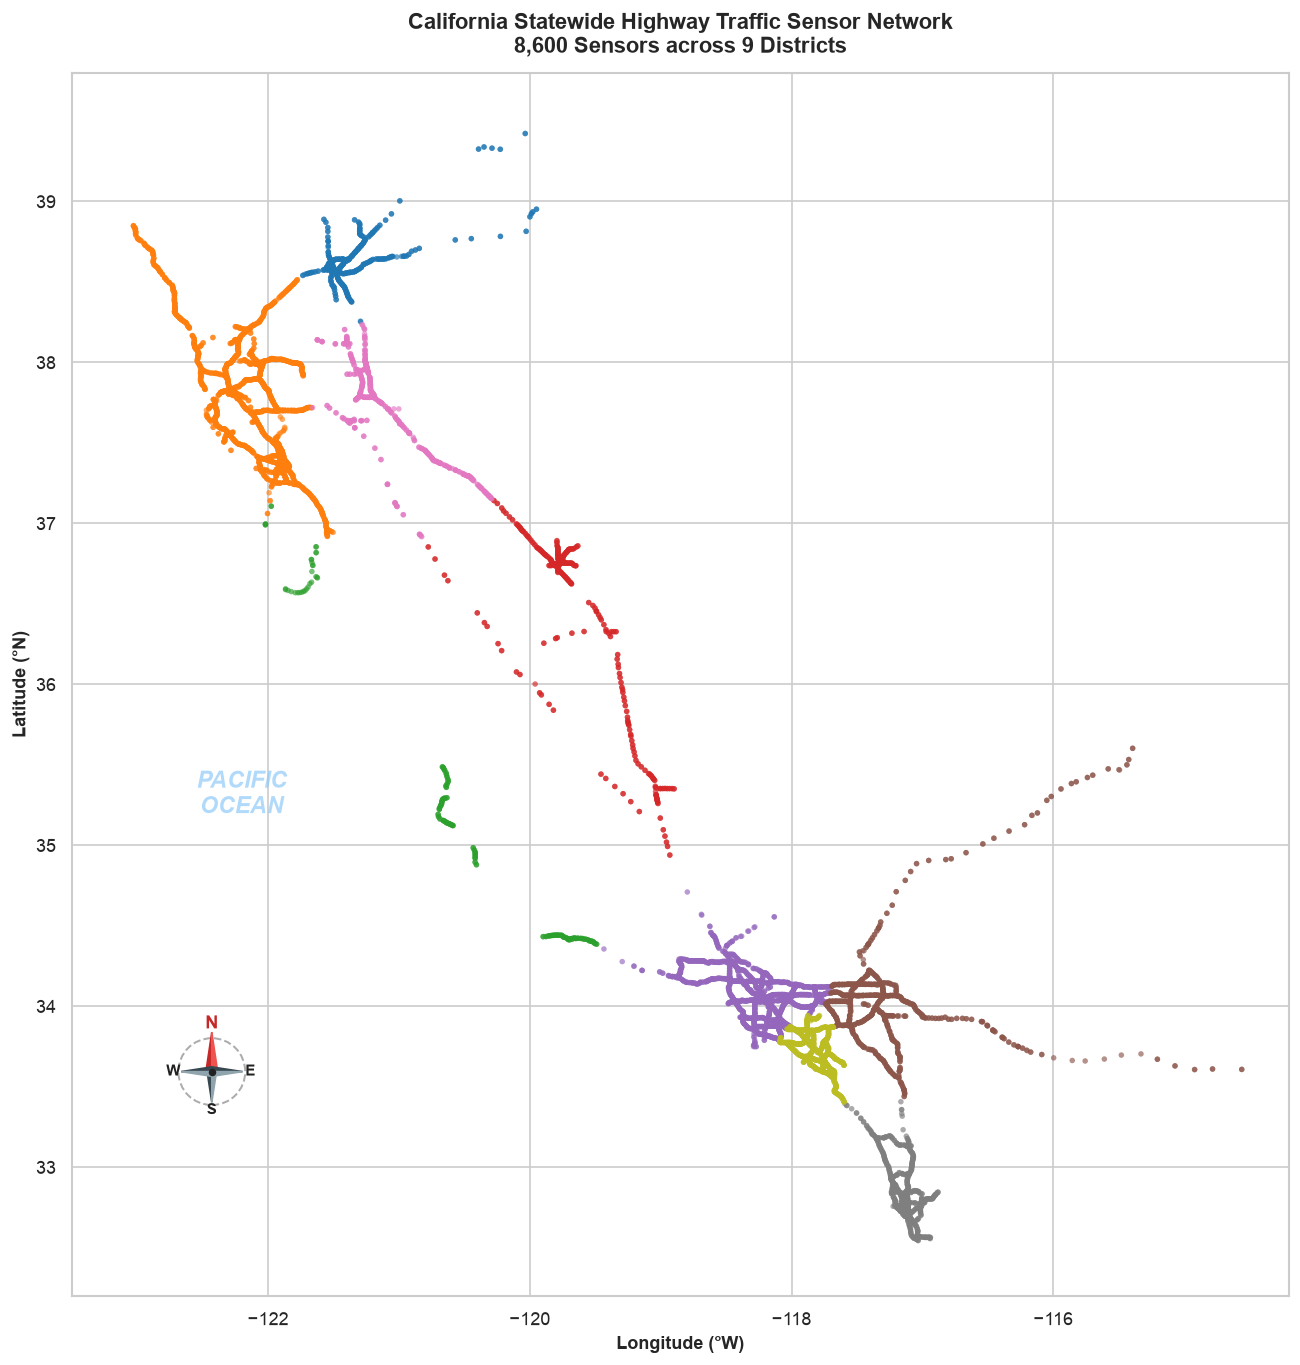

In [10]:
fig, ax = plt.subplots(figsize=(11, 12), dpi=120)

palette = sns.color_palette("tab10", n_colors=metadata_ca["District"].nunique())
for (d_id, d_name), color in zip(sorted(district_names.items()), palette):
    sub = metadata_ca[metadata_ca["District"] == d_id]
    ax.scatter(sub["Lng"], sub["Lat"], s=11, color=color, alpha=0.65,
               label=f"{d_name} ({len(sub):,})", edgecolor="none", zorder=2)

add_compass(ax, loc=(0.07, 0.14), size=0.09)

# Context labels
ax.text(-122.2, 35.2, "PACIFIC\nOCEAN", fontsize=14, fontweight="bold",
        fontstyle="italic", color="#90CAF9", alpha=0.7, ha="center")

ax.set_aspect(1.23)
ax.set_xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
ax.set_title("California Statewide Highway Traffic Sensor Network\n8,600 Sensors across 9 Districts",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(-123.5, -114.2)
ax.set_ylim(32.2, 39.8)
# ax.legend(title="Caltrans District", bbox_to_anchor=(1.02, 1), loc="upper left",
#           frameon=True, fontsize=9.5)

plt.tight_layout()
plt.show()


### 1.2 Highlighting the San Diego Challenge Subset (Red) vs. Rest of California (Blue)
The machine learning forecasting challenge isolates **San Diego County (716 sensors / 8.3% of the California network)**.
In the map below, the San Diego study stations are prominently highlighted in **red**, while all other California sensors are shown in **blue**.


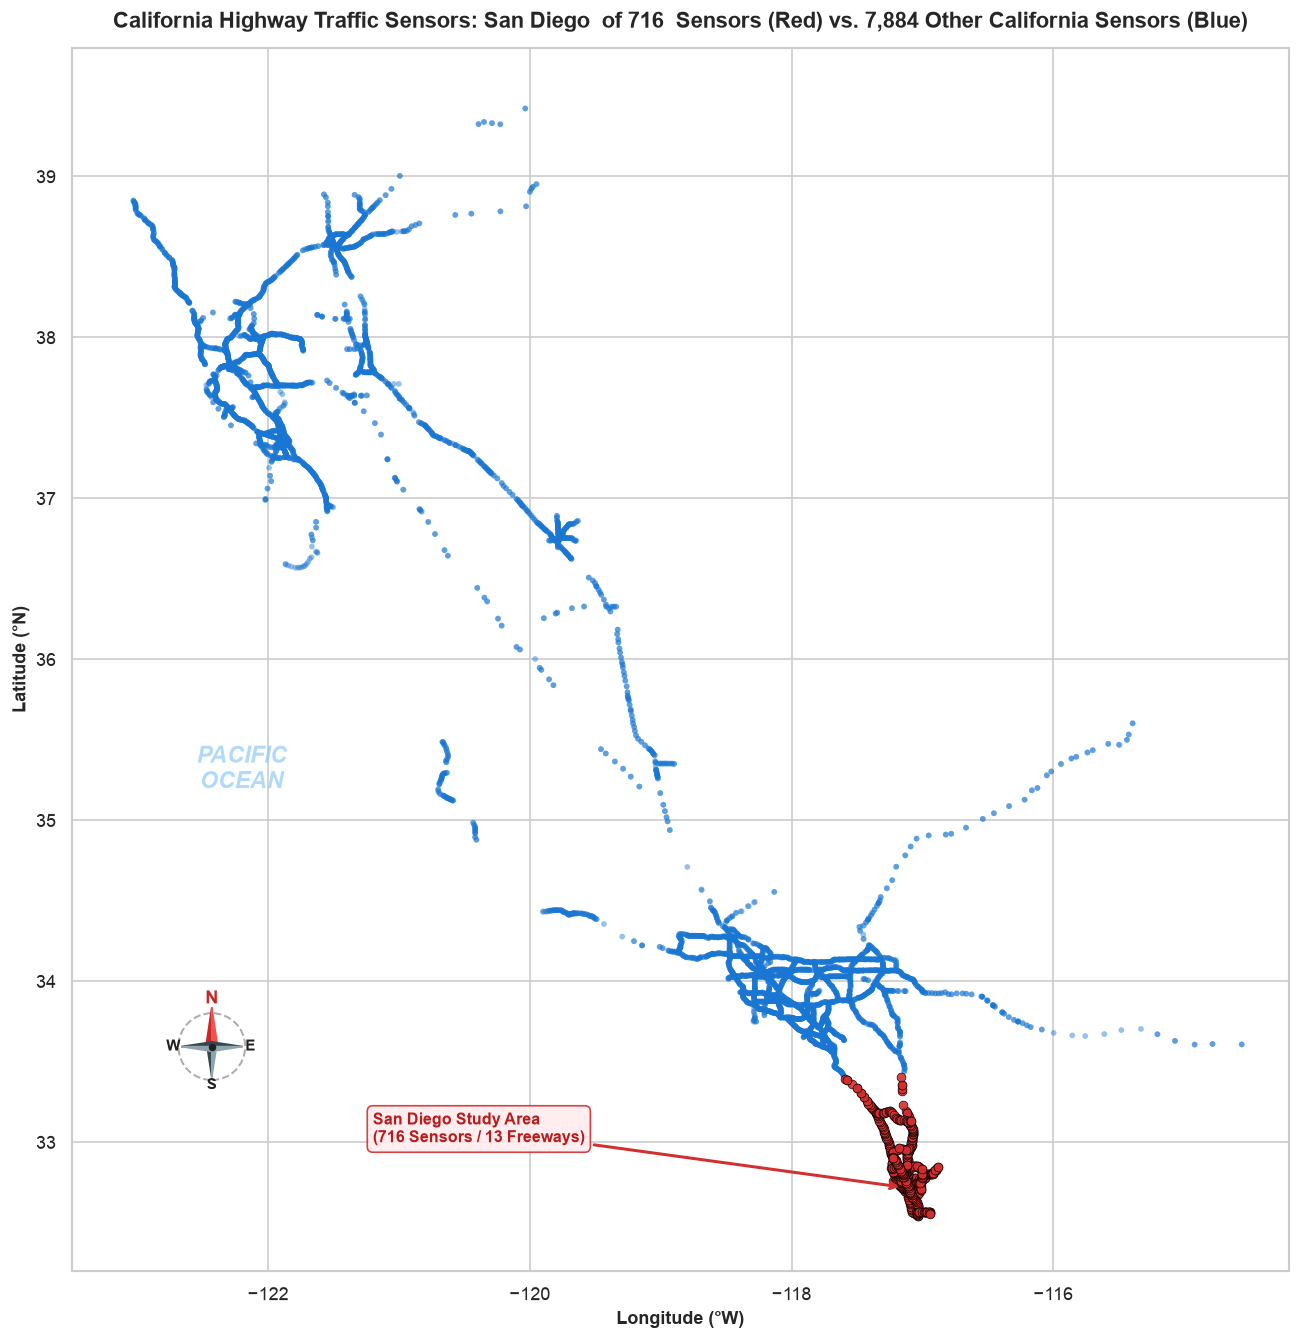

In [11]:
fig, ax = plt.subplots(figsize=(11, 12), dpi=120)

other_ca = metadata_ca[~metadata_ca["IsSanDiego"]]
sd = metadata_ca[metadata_ca["IsSanDiego"]]

# 1. Other California sensors in Blue
ax.scatter(other_ca["Lng"], other_ca["Lat"], s=12, color="#1976D2", alpha=0.45,
           label=f"Rest of California ({len(other_ca):,} sensors / 91.7%)", edgecolor="none", zorder=2)

# 2. San Diego study sensors in Red
ax.scatter(sd["Lng"], sd["Lat"], s=28, color="#D32F2F", alpha=0.9,
           label=f"San Diego Study Subset ({len(sd):,} sensors / 8.3%)",
           edgecolor="black", linewidth=0.4, zorder=4)

add_compass(ax, loc=(0.07, 0.14), size=0.09)

# Context and callout annotations
ax.text(-122.2, 35.2, "PACIFIC\nOCEAN", fontsize=14, fontweight="bold",
        fontstyle="italic", color="#90CAF9", alpha=0.7, ha="center")
ax.annotate("San Diego Study Area\n(716 Sensors / 13 Freeways)",
            xy=(-117.15, 32.72), xytext=(-121.2, 33.0),
            arrowprops=dict(arrowstyle="->", color="#D32F2F", lw=1.8),
            fontsize=9.5, fontweight="bold", color="#B71C1C",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#FFEBEE", edgecolor="#D32F2F", alpha=0.9),
            zorder=5)

ax.set_aspect(1.23)
ax.set_xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
ax.set_title("California Highway Traffic Sensors: San Diego  of 716  Sensors (Red) vs. 7,884 Other California Sensors (Blue)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(-123.5, -114.2)
ax.set_ylim(32.2, 39.8)
# ax.legend(title="Sensor Subset", bbox_to_anchor=(1.02, 1), loc="upper left",
#           frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


## 2. San Diego County Deep Dive: Sensor Setup & Freeway Corridors
We now narrow our focus to the San Diego study area.
We load the historical 2019 traffic flow series (`sd_his_2019.h5`) and extract the base highway name from `Fwy` (stripping the direction suffix like `-N` or `-S`) to identify the **13 distinct roads**.


In [12]:
metadata = metadata_sd.copy()
traffic = pd.read_hdf(DATA_DIR / "sd_his_2019.h5")
traffic.columns = traffic.columns.astype(str)

# Extract the base road name (13 unique roads)
metadata["Road"] = metadata["Fwy"].str.rsplit("-", n=1).str[0]

# Classify corridors into North-South vs East-West
ns_roads = ["I5", "I15", "I805", "SR125", "SR163"]
ew_roads = ["I8", "SR78", "SR94", "SR52", "SR56", "I905", "SR54", "SR11"]
metadata["CorridorType"] = metadata["Road"].apply(
    lambda r: "North-South" if r in ns_roads else "East-West"
)

# Compute sensor-level mean traffic flow
sensor_mean_flow = traffic.mean(axis=0).rename("MeanFlow")
metadata = metadata.merge(sensor_mean_flow, left_on="ID", right_index=True, how="left")

print(f"San Diego County Network: {metadata.shape[0]} sensors across {metadata['Road'].nunique()} distinct roads.")
print(f"Bounding Box: Lat [{metadata['Lat'].min():.4f}, {metadata['Lat'].max():.4f}] | Lng [{metadata['Lng'].min():.4f}, {metadata['Lng'].max():.4f}]")


San Diego County Network: 716 sensors across 13 distinct roads.
Bounding Box: Lat [32.5443, 33.4067] | Lng [-117.5916, -116.8807]


In [13]:
road_overview = metadata.groupby("Road").agg(
    Sensors=("ID", "count"),
    Directions=("Direction", lambda d: "/".join(sorted(d.unique()))),
    CorridorType=("CorridorType", "first"),
    MinLanes=("Lanes", "min"),
    MaxLanes=("Lanes", "max"),
    MinLat=("Lat", "min"),
    MaxLat=("Lat", "max"),
    MinLng=("Lng", "min"),
    MaxLng=("Lng", "max"),
    MeanFlow=("MeanFlow", "mean")
).sort_values("Sensors", ascending=False)

display(road_overview.round(2))


,Sensors,Directions,CorridorType,MinLanes,MaxLanes,MinLat,MaxLat,MinLng,MaxLng,MeanFlow
Road,,,,,,,,,,
I5,181,N/S,North-South,2,6,32.54,33.39,-117.59,-117.03,270.98
I15,127,N/S,North-South,2,8,32.70,33.41,-117.16,-117.07,323.39
I805,100,N/S,North-South,2,6,32.55,32.90,-117.22,-117.04,269.30
I8,86,E/W,East-West,2,6,32.76,32.84,-117.22,-116.88,234.07
SR78,44,E/W,East-West,2,6,33.13,33.19,-117.35,-117.09,197.72
SR94,36,E/W,East-West,3,6,32.71,32.75,-117.15,-117.01,232.68
SR52,31,E/W,East-West,2,4,32.84,32.85,-117.23,-117.02,140.51
SR125,30,N/S,North-South,2,4,32.70,32.83,-117.02,-117.00,143.07
SR163,25,N/S,North-South,2,6,32.75,32.86,-117.16,-117.11,246.16


## 3. Complete Highway Network Map (13 Roads Highlighted + Cartographic Compass)
The visualization below presents the entire San Diego sensor network:
- **Aspect Ratio Correction**: In San Diego (latitude ~32.8°N), one degree of longitude covers approximately $\cos(32.8^\circ) \approx 0.84$ degrees of latitude. We set the aspect ratio to $1 / \cos(32.8^\circ) \approx 1.19$ to display distances without geographic distortion.
- **Corridor Highlighting (13 Roads)**: Each road is assigned a distinct color from a dedicated palette. Connected lines trace the freeway trajectory through sequentially ordered sensors along each travel direction.
- **Cartographic Compass Rose**: Placed in the open Pacific Ocean waters off Point Loma / San Ysidro (southwest corner), showing cardinal directions (**N / S / E / W**).
- **Road Badges**: Prominent labels mark the centroid of each highway.


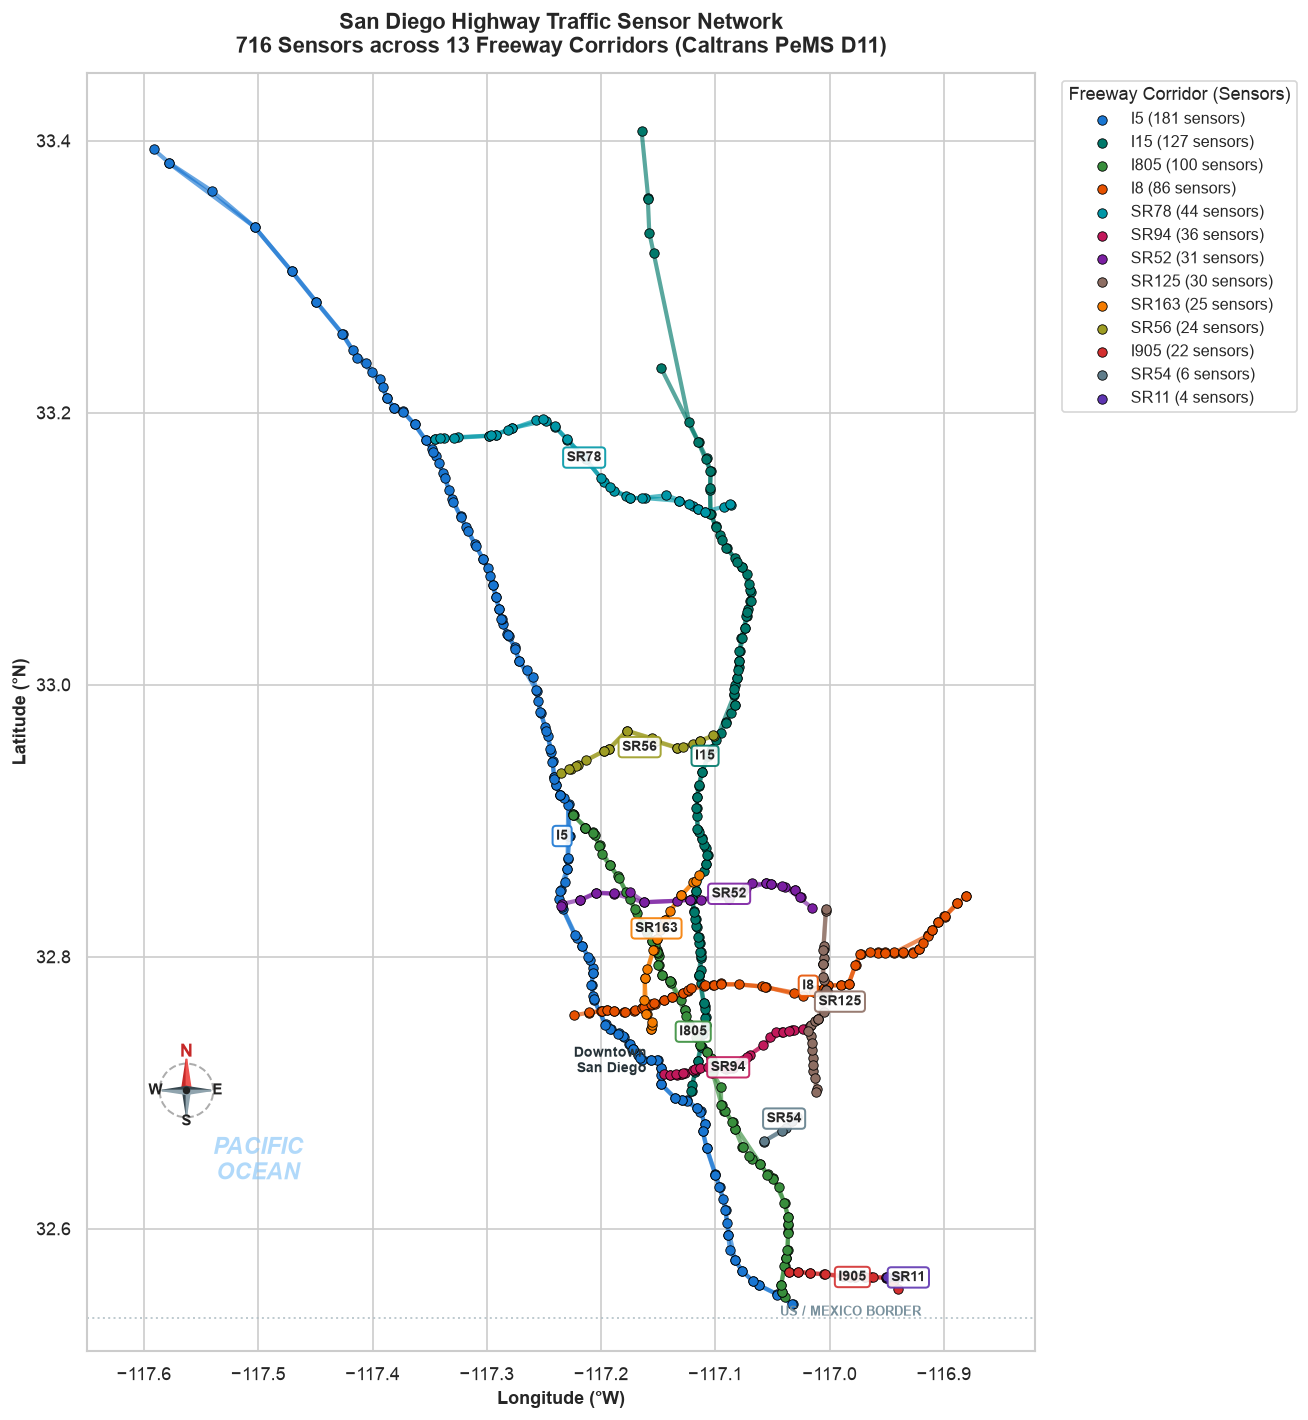

In [14]:
fig, ax = plt.subplots(figsize=(13, 12), dpi=120)

# Curated high-contrast color palette for the 13 roads
road_names = ["I5", "I15", "I805", "I8", "SR78", "SR94", "SR52", "SR125", "SR163", "SR56", "I905", "SR54", "SR11"]
colors = [
    "#1976D2",  # I5: Strong Blue (coastal spine)
    "#00796B",  # I15: Deep Teal (inland spine)
    "#388E3C",  # I805: Forest Green (central bypass)
    "#E65100",  # I8: Vivid Orange (major east-west interstate)
    "#0097A7",  # SR78: Cyan (north county connector)
    "#C2185B",  # SR94: Magenta/Pink (south-central east-west)
    "#7B1FA2",  # SR52: Deep Purple (cross-county connector)
    "#8D6E63",  # SR125: Warm Brown (east county north-south)
    "#F57C00",  # SR163: Amber (Balboa Park / Kearny Mesa)
    "#9E9D24",  # SR56: Olive/Lime (Ted Williams connector)
    "#D32F2F",  # I905: Deep Red (border corridor)
    "#607D8B",  # SR54: Blue Grey (south bay connector)
    "#5E35B1",  # SR11: Indigo (Otay Mesa border tollway)
]
road_colors = dict(zip(road_names, colors))

# 1. Plot freeway trajectories (lines) by connecting sorted sensors along each direction
for road in road_names:
    road_data = metadata[metadata["Road"] == road]
    color = road_colors[road]
    for fwy, fwy_data in road_data.groupby("Fwy"):
        direction = fwy.split("-")[1]
        sort_col = "Lat" if direction in ["N", "S"] else "Lng"
        sorted_sensors = fwy_data.sort_values(sort_col)
        ax.plot(sorted_sensors["Lng"], sorted_sensors["Lat"],
                color=color, lw=2.5, alpha=0.65, zorder=2)

# 2. Plot sensor scatter points
for road in road_names:
    road_data = metadata[metadata["Road"] == road]
    color = road_colors[road]
    ax.scatter(road_data["Lng"], road_data["Lat"],
               color=color, s=32, edgecolor="black", linewidth=0.5,
               label=f"{road} ({len(road_data)} sensors)", zorder=3)

# 3. Add road badge annotations at median coordinates
for road in road_names:
    road_data = metadata[metadata["Road"] == road]
    med_lat = road_data["Lat"].median()
    med_lng = road_data["Lng"].median()
    offset_lat = 0.008 if road in ["SR163", "SR54"] else 0.0
    offset_lng = 0.015 if road in ["SR125", "SR11"] else 0.0
    ax.text(med_lng + offset_lng, med_lat + offset_lat, road,
            fontsize=8.5, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=road_colors[road], linewidth=1.2, alpha=0.9),
            zorder=4)

# 4. Compass rose in southwest quadrant (Pacific Ocean)
add_compass(ax, loc=(0.06, 0.16), size=0.09)

# 5. Geographic context annotations
ax.text(-117.50, 32.65, "PACIFIC\nOCEAN", fontsize=14, fontweight="bold",
        fontstyle="italic", color="#90CAF9", alpha=0.7, ha="center", va="center")
ax.text(-117.16, 32.715, "Downtown\nSan Diego", fontsize=8.5, fontweight="bold",
        color="#263238", ha="right")
ax.axhline(y=32.534, color="#B0BEC5", linestyle=":", lw=1.2, alpha=0.8)
ax.text(-116.92, 32.536, "US / MEXICO BORDER", fontsize=7.5, fontweight="bold",
        color="#78909C", ha="right")

# Geographically correct aspect ratio
ax.set_aspect(1.19)
ax.set_xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
ax.set_title("San Diego Highway Traffic Sensor Network\n716 Sensors across 13 Freeway Corridors (Caltrans PeMS D11)",
             fontsize=13, fontweight="bold", pad=12)

ax.set_xlim(-117.65, -116.82)
ax.set_ylim(32.51, 33.45)
ax.legend(title="Freeway Corridor (Sensors)", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=True, fontsize=9.5, title_fontsize=10.5)

plt.tight_layout()
plt.show()


## 4. Cardinal Directionality Analysis (N / S / E / W)
Every sensor station monitors traffic traveling in a specific cardinal direction (`Direction`):
- **Northbound (N)**: 242 sensors (33.8%)
- **Southbound (S)**: 221 sensors (30.9%)
- **Westbound (W)**: 137 sensors (19.1%)
- **Eastbound (E)**: 116 sensors (16.2%)

Notice how this aligns with the cardinal compass:
- The **North-South axis** represents **64.7%** of the entire network, centered on commuter flow between North County, the Sorrento Valley tech hub, Downtown, and the border.
- The **East-West axis** represents **35.3%**, connecting coastal employment centers with inland residential valleys.


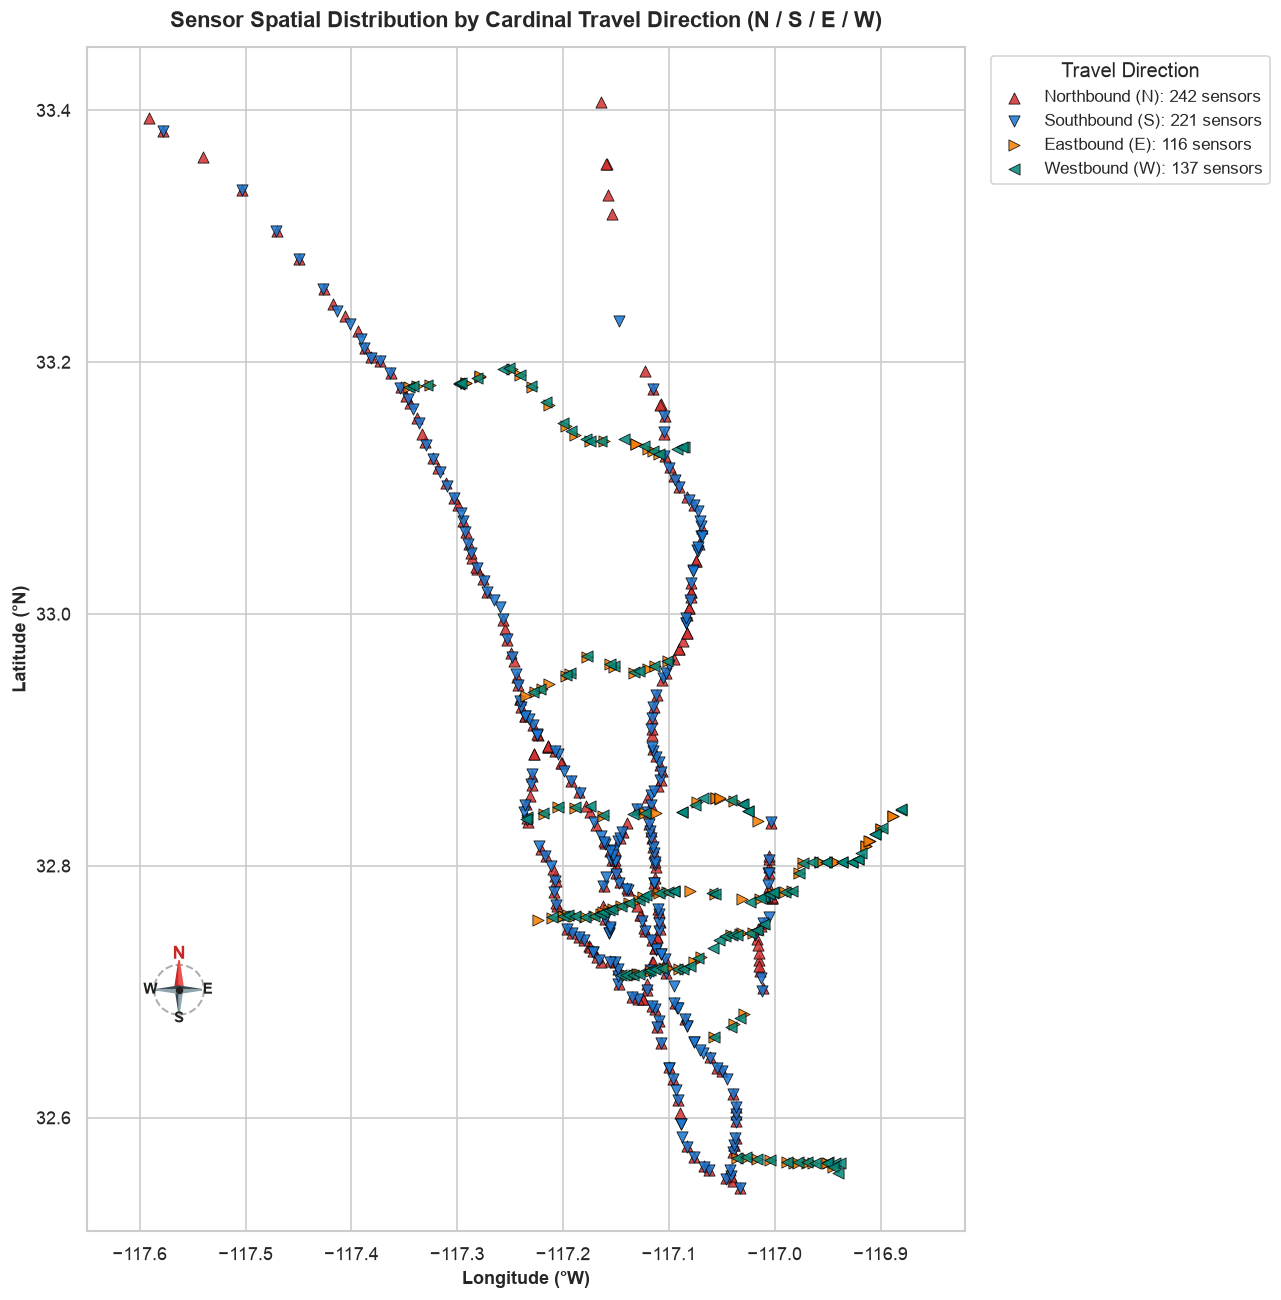

In [15]:
dir_config = {
    "N": {"color": "#D32F2F", "marker": "^", "label": "Northbound (N)"},
    "S": {"color": "#1976D2", "marker": "v", "label": "Southbound (S)"},
    "E": {"color": "#F57C00", "marker": ">", "label": "Eastbound (E)"},
    "W": {"color": "#00897B", "marker": "<", "label": "Westbound (W)"}
}

fig, ax = plt.subplots(figsize=(12, 11), dpi=120)

for d, cfg in dir_config.items():
    sub = metadata[metadata["Direction"] == d]
    ax.scatter(sub["Lng"], sub["Lat"], c=cfg["color"], marker=cfg["marker"],
               s=45, edgecolor="black", linewidth=0.5,
               label=f"{cfg['label']}: {len(sub)} sensors", alpha=0.85, zorder=3)

add_compass(ax, loc=(0.06, 0.16), size=0.09)

ax.set_aspect(1.19)
ax.set_xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
ax.set_title("Sensor Spatial Distribution by Cardinal Travel Direction (N / S / E / W)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(-117.65, -116.82)
ax.set_ylim(32.51, 33.45)
ax.legend(title="Travel Direction", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


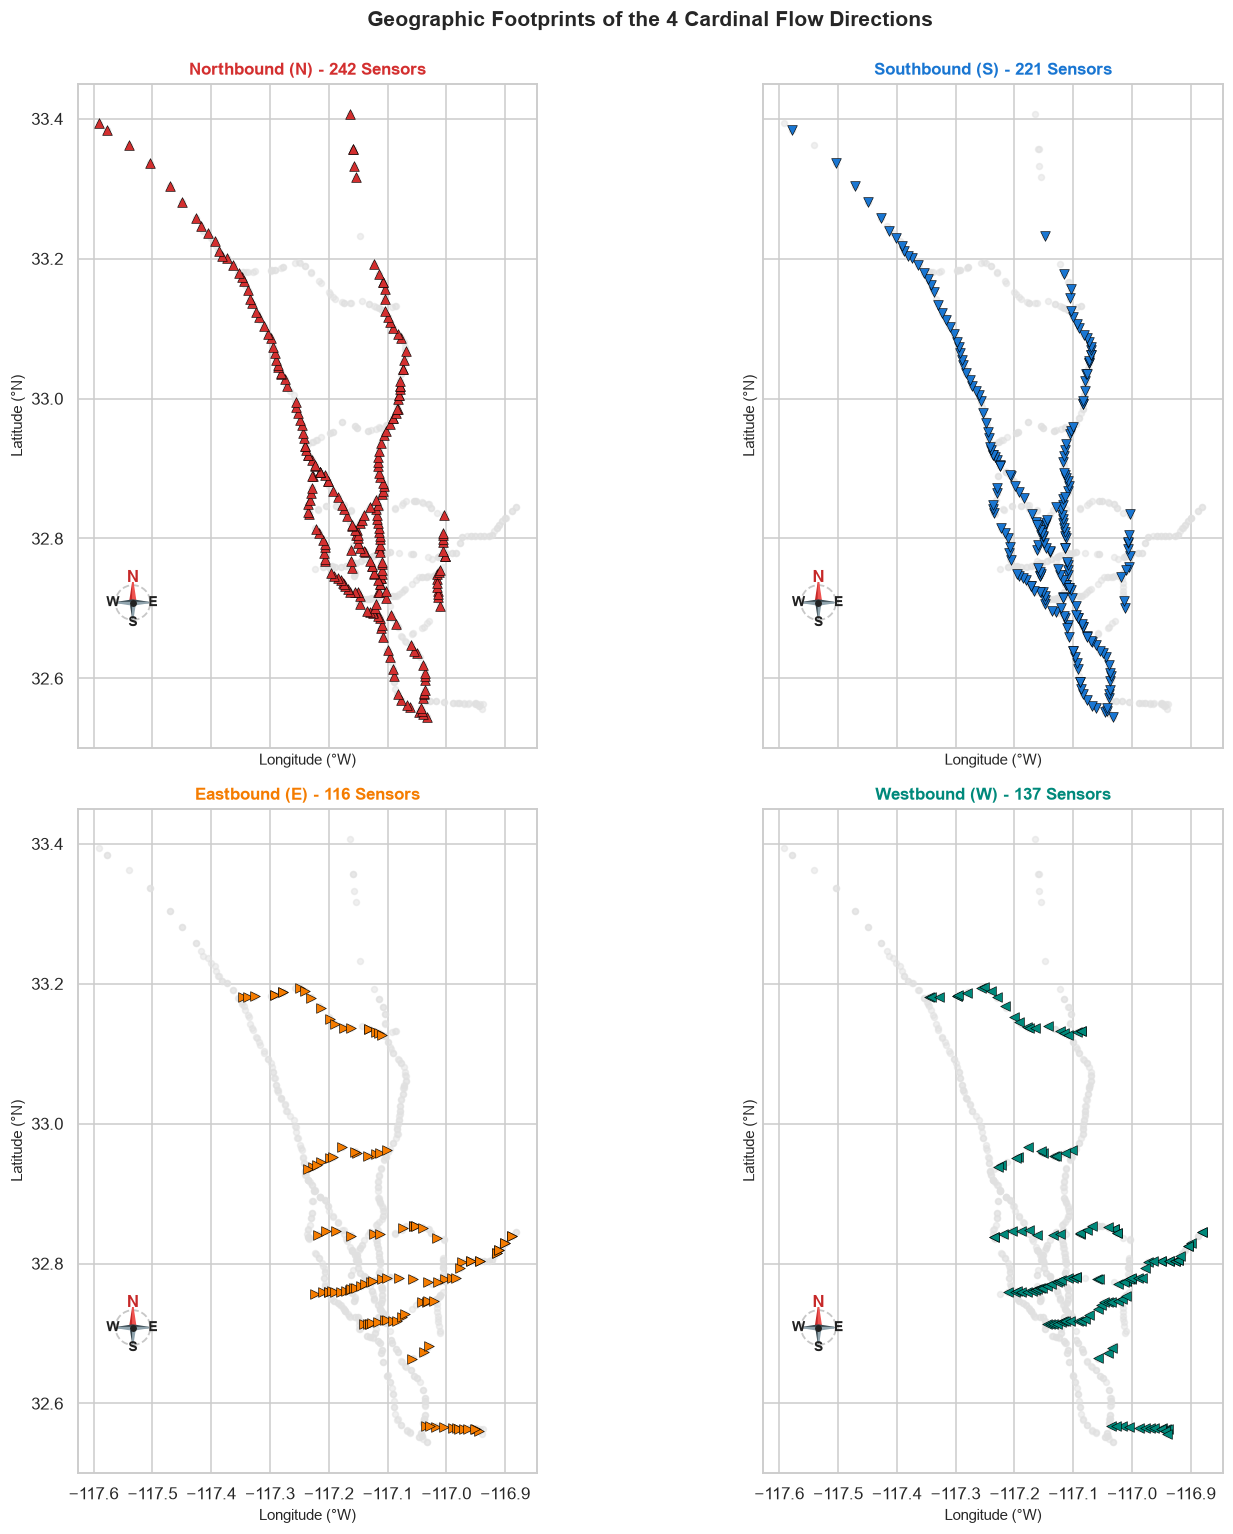

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), dpi=110, sharex=True, sharey=True)
axes = axes.flatten()

order = ["N", "S", "E", "W"]
titles = [
    "Northbound (N) - 242 Sensors",
    "Southbound (S) - 221 Sensors",
    "Eastbound (E) - 116 Sensors",
    "Westbound (W) - 137 Sensors"
]

for idx, d in enumerate(order):
    ax = axes[idx]
    cfg = dir_config[d]
    sub = metadata[metadata["Direction"] == d]
    
    # Background: all sensors in light grey
    ax.scatter(metadata["Lng"], metadata["Lat"], color="#E0E0E0", s=15, alpha=0.5, zorder=1)
    
    # Active direction sensors
    ax.scatter(sub["Lng"], sub["Lat"], c=cfg["color"], marker=cfg["marker"],
               s=40, edgecolor="black", linewidth=0.4, zorder=3)
    
    # Mini compass in each panel
    add_compass(ax, loc=(0.06, 0.16), size=0.12, ring_alpha=0.4)
    
    ax.set_aspect(1.19)
    ax.set_title(titles[idx], fontsize=11, fontweight="bold", color=cfg["color"])
    ax.set_xlabel("Longitude (°W)", fontsize=9.5)
    ax.set_ylabel("Latitude (°N)", fontsize=9.5)

plt.suptitle("Geographic Footprints of the 4 Cardinal Flow Directions",
             fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()


In [17]:
road_dir_matrix = pd.crosstab(metadata["Road"], metadata["Direction"], margins=True, margins_name="Total")
road_dir_matrix = road_dir_matrix.loc[sorted(metadata["Road"].unique()) + ["Total"], ["N", "S", "E", "W", "Total"]]
display(road_dir_matrix)


Direction,N,S,E,W,Total
Road,,,,,
I15,69,58,0,0,127
I5,95,86,0,0,181
I8,0,0,39,47,86
I805,49,51,0,0,100
I905,0,0,11,11,22
SR11,0,0,1,3,4
SR125,19,11,0,0,30
SR163,10,15,0,0,25
SR52,0,0,13,18,31


## 5. Corridor Classification: North-South Arterial Spines vs. East-West Connectors
The 13 roads split into two functional groups:
1. **North-South Arterial Spines (5 roads, 463 sensors / 64.7%)**:
   - `I5` (181 sensors): Primary coastal backbone connecting San Diego to Orange/LA County.
   - `I15` (127 sensors): Inland arterial connecting Mission Valley to Escondido and Riverside County.
   - `I805` (100 sensors): Central inland bypass between Chula Vista and the I-5 merge at Sorrento Valley.
   - `SR125` (30 sensors): East County north-south corridor.
   - `SR163` (25 sensors): Commuter artery from Downtown through Balboa Park into Kearny Mesa.
2. **East-West Transversal Connectors (8 roads, 253 sensors / 35.3%)**:
   - `I8` (86 sensors): Primary cross-county interstate connecting the ocean to eastern mountains.
   - `SR78` (44 sensors): North County connector linking Oceanside, Vista, San Marcos, and Escondido.
   - `SR94` (36 sensors): Linking Downtown to Spring Valley.
   - `SR52` (31 sensors): Cross-town expressway from La Jolla to Santee.
   - `SR56` (24 sensors): Ted Williams Freeway connecting coastal I-5 to inland I-15.
   - `I905` (22 sensors): Border access corridor along Otay Mesa.
   - `SR54` (6 sensors): South Bay connector between National City and Jamacha.
   - `SR11` (4 sensors): Otay Mesa East border port connector.


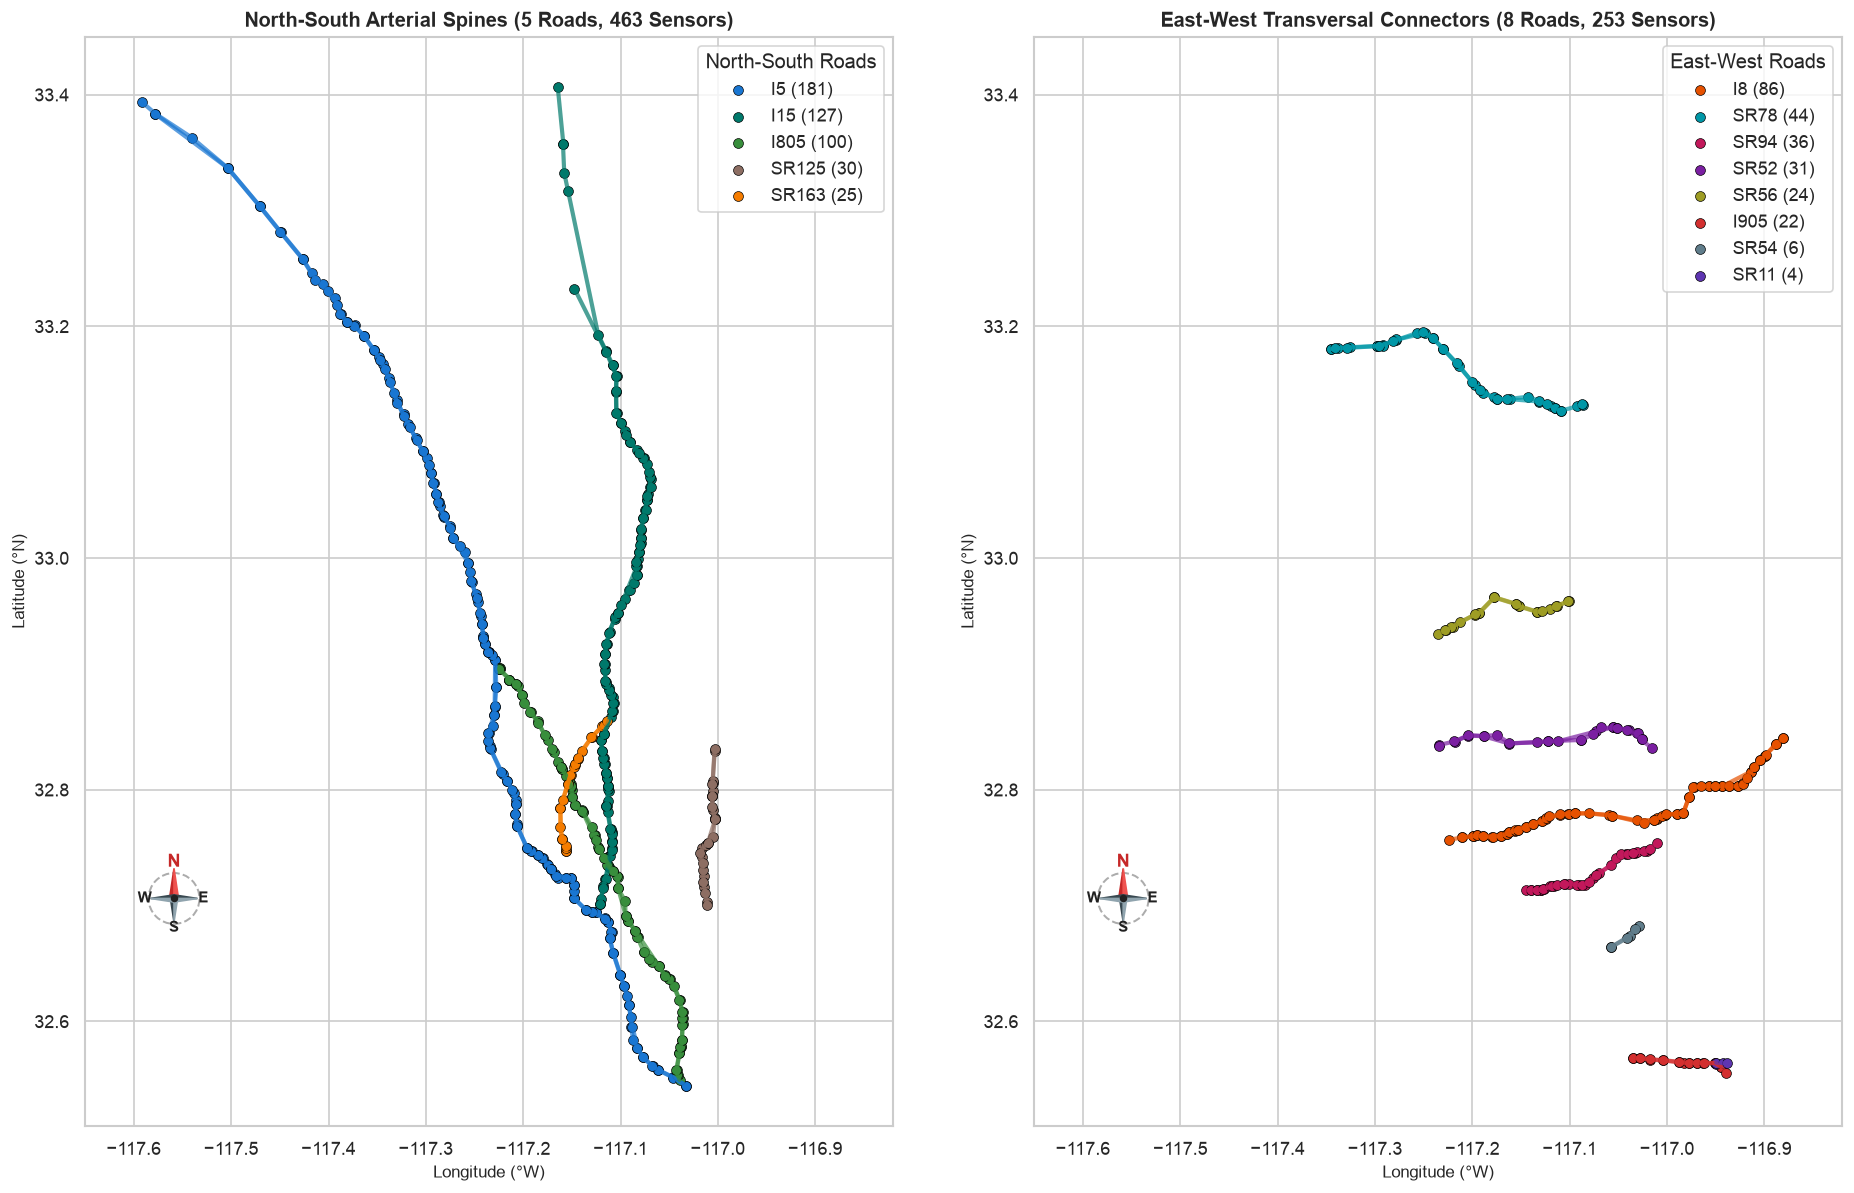

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10), dpi=120)

# Panel 1: North-South Corridors
ax_ns = axes[0]
ns_meta = metadata[metadata["CorridorType"] == "North-South"]
for road in ns_roads:
    road_data = ns_meta[ns_meta["Road"] == road]
    color = road_colors[road]
    for fwy, fwy_data in road_data.groupby("Fwy"):
        sorted_sensors = fwy_data.sort_values("Lat")
        ax_ns.plot(sorted_sensors["Lng"], sorted_sensors["Lat"],
                   color=color, lw=2.5, alpha=0.7)
    ax_ns.scatter(road_data["Lng"], road_data["Lat"], color=color, s=35,
                  edgecolor="black", linewidth=0.4, label=f"{road} ({len(road_data)})")

add_compass(ax_ns, loc=(0.06, 0.16), size=0.10)
ax_ns.set_aspect(1.19)
ax_ns.set_title("North-South Arterial Spines (5 Roads, 463 Sensors)", fontsize=12, fontweight="bold")
ax_ns.set_xlabel("Longitude (°W)", fontsize=10)
ax_ns.set_ylabel("Latitude (°N)", fontsize=10)
ax_ns.set_xlim(-117.65, -116.82)
ax_ns.set_ylim(32.51, 33.45)
ax_ns.legend(title="North-South Roads", loc="upper right")

# Panel 2: East-West Corridors
ax_ew = axes[1]
ew_meta = metadata[metadata["CorridorType"] == "East-West"]
for road in ew_roads:
    road_data = ew_meta[ew_meta["Road"] == road]
    color = road_colors[road]
    for fwy, fwy_data in road_data.groupby("Fwy"):
        sorted_sensors = fwy_data.sort_values("Lng")
        ax_ew.plot(sorted_sensors["Lng"], sorted_sensors["Lat"],
                   color=color, lw=2.5, alpha=0.7)
    ax_ew.scatter(road_data["Lng"], road_data["Lat"], color=color, s=35,
                  edgecolor="black", linewidth=0.4, label=f"{road} ({len(road_data)})")

add_compass(ax_ew, loc=(0.06, 0.16), size=0.10)
ax_ew.set_aspect(1.19)
ax_ew.set_title("East-West Transversal Connectors (8 Roads, 253 Sensors)", fontsize=12, fontweight="bold")
ax_ew.set_xlabel("Longitude (°W)", fontsize=10)
ax_ew.set_ylabel("Latitude (°N)", fontsize=10)
ax_ew.set_xlim(-117.65, -116.82)
ax_ew.set_ylim(32.51, 33.45)
ax_ew.legend(title="East-West Roads", loc="upper right")

plt.tight_layout()
plt.show()


## 6. Infrastructure Capacity & Highway Lane Distribution
The `Lanes` attribute records the number of through-lanes monitored at each station (ranging from 2 to 6+ lanes):
- Highway capacity is concentrated along the **I-5 and I-805 corridors** through Clairemont, University City, and Chula Vista, where stations monitor 5–6 lanes.
- Peripheral connectors (e.g., SR-54, SR-11, SR-125) typically feature 2–3 lanes per direction.
- Abrupt changes in lane counts along a corridor highlight structural capacity bottlenecks where congestion frequently originates.


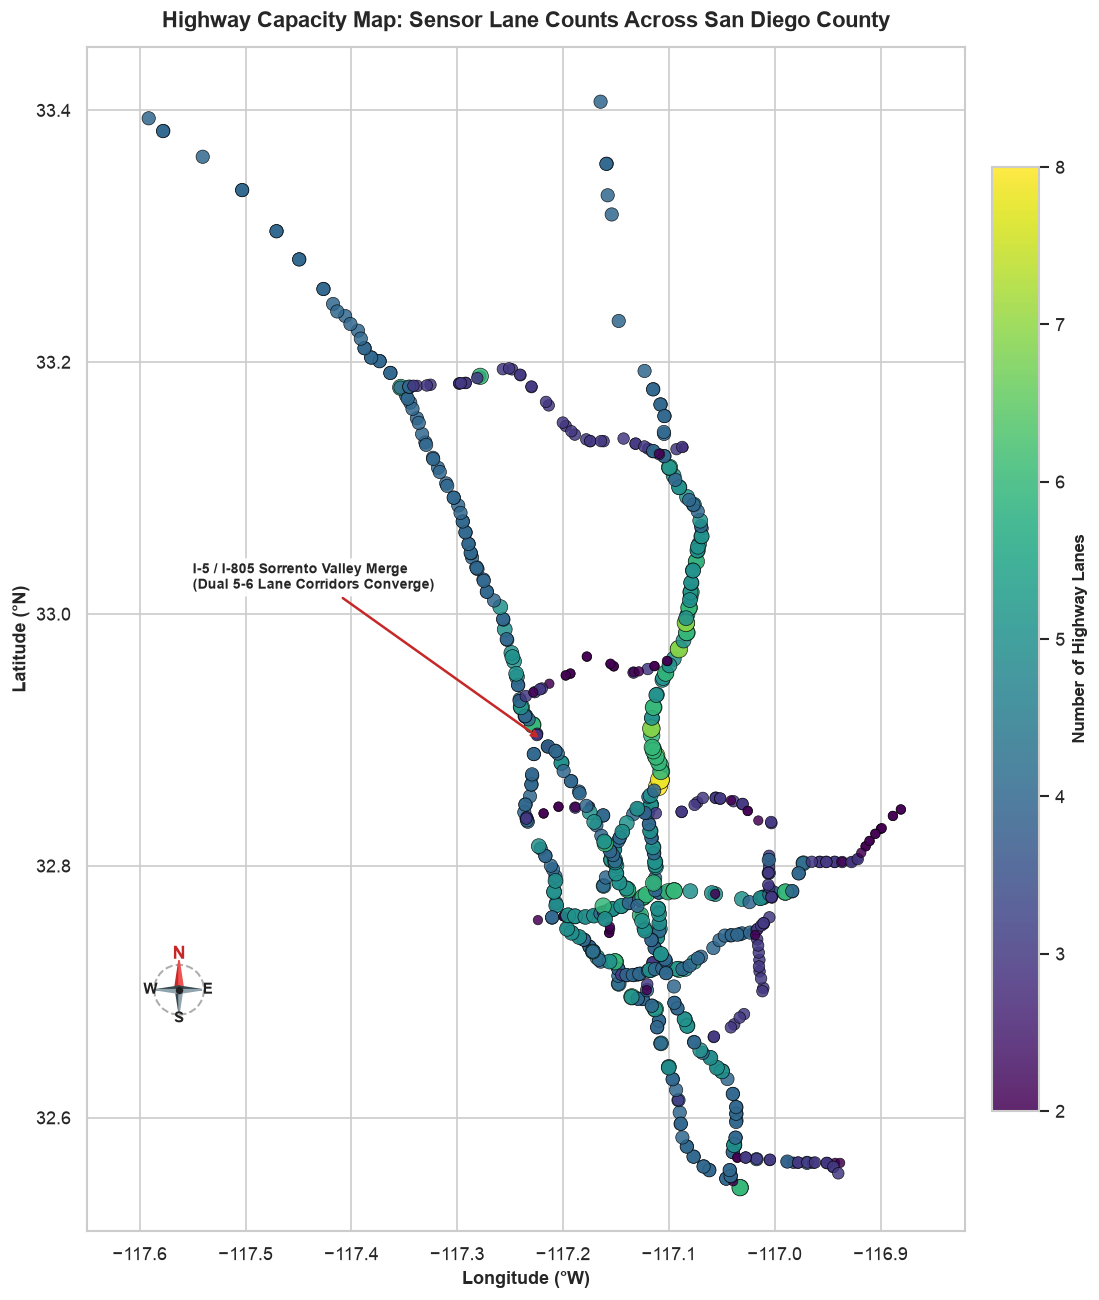

In [19]:
fig, ax = plt.subplots(figsize=(12, 11), dpi=120)

scatter = ax.scatter(
    metadata["Lng"], metadata["Lat"],
    c=metadata["Lanes"], s=metadata["Lanes"] * 16,
    cmap="viridis", edgecolor="black", linewidth=0.4, alpha=0.85, zorder=3
)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Number of Highway Lanes", fontsize=10, fontweight="bold")
cbar.set_ticks(sorted(metadata["Lanes"].unique()))

add_compass(ax, loc=(0.06, 0.16), size=0.09)

# Annotate key bottleneck merge
ax.annotate(
    "I-5 / I-805 Sorrento Valley Merge\n(Dual 5-6 Lane Corridors Converge)",
    xy=(-117.22, 32.90), xytext=(-117.55, 33.02),
    arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.5),
    fontsize=8.5, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9)
)

ax.set_aspect(1.19)
ax.set_xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
ax.set_title("Highway Capacity Map: Sensor Lane Counts Across San Diego County",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(-117.65, -116.82)
ax.set_ylim(32.51, 33.45)

plt.tight_layout()
plt.show()


## 7. Geospatial Traffic Flow Intensity & Congestion Hotspots
By coupling the sensor coordinates with the 2019 historical traffic volume, we map the geographic distribution of traffic flow intensity (average vehicles per 5-minute interval).


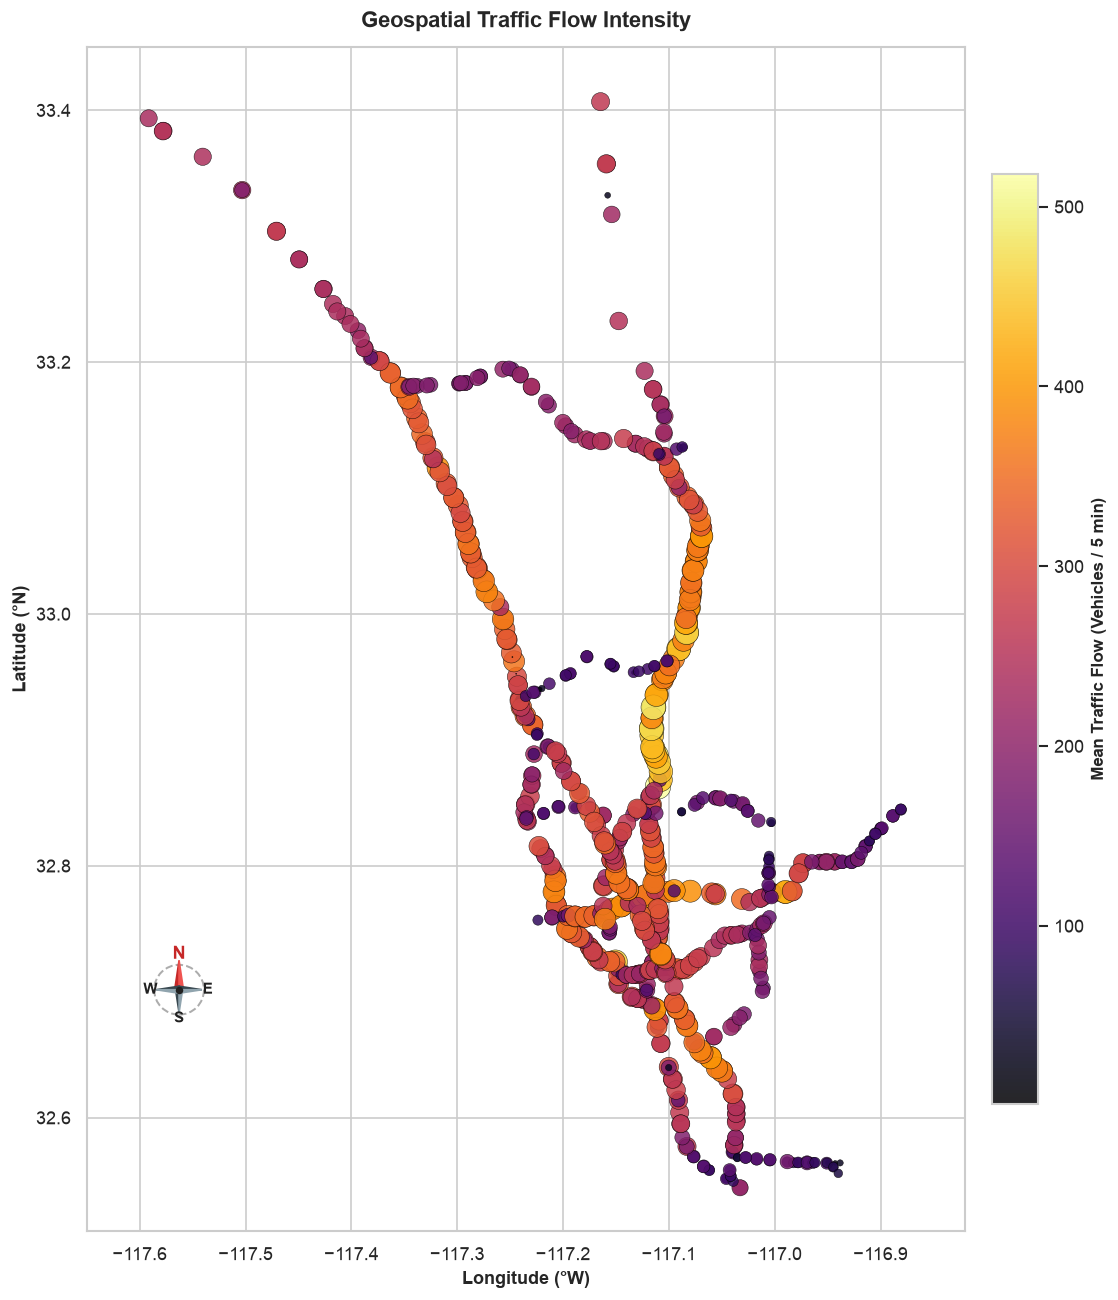

In [20]:
fig, ax = plt.subplots(figsize=(12, 11), dpi=120)

flow_scatter = ax.scatter(
    metadata["Lng"], metadata["Lat"],
    c=metadata["MeanFlow"], s=metadata["MeanFlow"] * 0.45,
    cmap="inferno", edgecolor="black", linewidth=0.3, alpha=0.85, zorder=3
)

cbar = plt.colorbar(flow_scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Mean Traffic Flow (Vehicles / 5 min)", fontsize=10, fontweight="bold")

add_compass(ax, loc=(0.06, 0.16), size=0.09)

ax.set_aspect(1.19)
ax.set_xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
ax.set_title("Geospatial Traffic Flow Intensity",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(-117.65, -116.82)
ax.set_ylim(32.51, 33.45)

plt.tight_layout()
plt.show()


In [21]:
top_flow_sensors = metadata.sort_values("MeanFlow", ascending=False).head(10)[
    ["ID", "Road", "Fwy", "Direction", "Lanes", "Lat", "Lng", "MeanFlow"]
].copy()
top_flow_sensors["Lat"] = top_flow_sensors["Lat"].round(4)
top_flow_sensors["Lng"] = top_flow_sensors["Lng"].round(4)
top_flow_sensors["MeanFlow"] = top_flow_sensors["MeanFlow"].round(1)
display(top_flow_sensors)


,ID,Road,Fwy,Direction,Lanes,Lat,Lng,MeanFlow
293,1120611,I15,I15-N,N,8,32.8630,-117.1103,518.2
368,1115838,I15,I15-S,S,6,32.9258,-117.1147,487.8
297,1122469,I15,I15-N,N,7,32.8875,-117.1121,484.2
300,1115739,I15,I15-N,N,6,32.9089,-117.1162,483.3
366,1122479,I15,I15-S,S,7,32.9089,-117.1166,466.1
311,1123031,I15,I15-N,N,6,32.9852,-117.0832,464.5
302,1115749,I15,I15-N,N,6,32.9258,-117.1141,461.1
21,1117748,I5,I5-N,N,6,32.7236,-117.1505,460.0
362,1108607,I15,I15-S,S,6,32.8820,-117.1096,455.4
307,1123003,I15,I15-N,N,6,32.9722,-117.0908,452.4


## 8. Spatial Proximity & Sensor Graph Topology (for Spatiotemporal Deep Learning)
In spatiotemporal deep learning models (such as **STGCN**, **DCRNN**, **Graph WaveNet**, and **ASTGCN**), traffic sensors represent graph nodes $\mathcal{V}$, and edges $\mathcal{E}$ are constructed using physical roadway distance:
$$W_{ij} = \begin{cases} \exp\left(-\frac{\text{dist}(v_i, v_j)^2}{\sigma^2}\right) & \text{if dist}(v_i, v_j) \le \kappa \\ 0 & \text{otherwise} \end{cases}$$

Understanding the spatial distance distribution is essential for parameterizing $\sigma$ (the spatial kernel bandwidth) and $\kappa$ (the sparsity distance threshold).


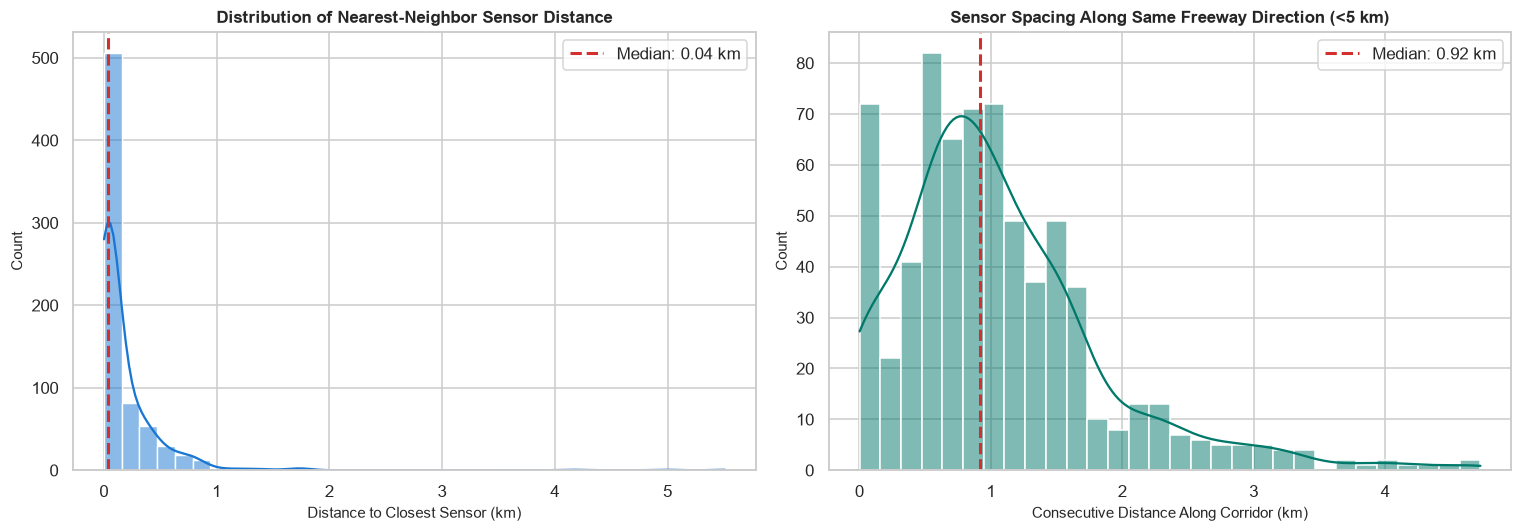

Network Spatial Extent: 111.2 km span
Median Nearest Neighbor: 0.04 km (Mean: 0.18 km)
Median Freeway Sensor Spacing: 0.92 km (Mean: 1.10 km)


In [22]:
# Compute pairwise Haversine distance matrix (in kilometers)
lat = np.radians(metadata["Lat"].values)
lng = np.radians(metadata["Lng"].values)

dlat = lat[:, None] - lat[None, :]
dlng = lng[:, None] - lng[None, :]
a = np.sin(dlat / 2)**2 + np.cos(lat[:, None]) * np.cos(lat[None, :]) * np.sin(dlng / 2)**2
dist_km = 6371.0 * 2 * np.arcsin(np.sqrt(a))

# Nearest neighbor distance (excluding self-distance of 0)
np.fill_diagonal(dist_km, np.inf)
nn_dist = dist_km.min(axis=1)

# Consecutive sensor distance along the same freeway direction
freeway_spacings = []
for fwy, group in metadata.groupby("Fwy"):
    direction = fwy.split("-")[1]
    sort_col = "Lat" if direction in ["N", "S"] else "Lng"
    sorted_group = group.sort_values(sort_col)
    s_lat = np.radians(sorted_group["Lat"].values)
    s_lng = np.radians(sorted_group["Lng"].values)
    d_lat = np.diff(s_lat)
    d_lng = np.diff(s_lng)
    h_a = np.sin(d_lat / 2)**2 + np.cos(s_lat[:-1]) * np.cos(s_lat[1:]) * np.sin(d_lng / 2)**2
    step_km = 6371.0 * 2 * np.arcsin(np.sqrt(h_a))
    freeway_spacings.extend(step_km)

freeway_spacings = np.array(freeway_spacings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Histogram of nearest-neighbor distance
sns.histplot(nn_dist, bins=35, kde=True, ax=axes[0], color="#1976D2")
axes[0].axvline(np.median(nn_dist), color="#D32F2F", linestyle="--", lw=2,
                label=f"Median: {np.median(nn_dist):.2f} km")
axes[0].set_title("Distribution of Nearest-Neighbor Sensor Distance", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Distance to Closest Sensor (km)", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
axes[0].legend()

# Histogram of consecutive spacing along the same freeway
sns.histplot(freeway_spacings[freeway_spacings < 5], bins=30, kde=True, ax=axes[1], color="#00796B")
axes[1].axvline(np.median(freeway_spacings), color="#D32F2F", linestyle="--", lw=2,
                label=f"Median: {np.median(freeway_spacings):.2f} km")
axes[1].set_title("Sensor Spacing Along Same Freeway Direction (<5 km)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Consecutive Distance Along Corridor (km)", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Network Spatial Extent: {dist_km[dist_km < np.inf].max():.1f} km span")
print(f"Median Nearest Neighbor: {np.median(nn_dist):.2f} km (Mean: {np.mean(nn_dist):.2f} km)")
print(f"Median Freeway Sensor Spacing: {np.median(freeway_spacings):.2f} km (Mean: {np.mean(freeway_spacings):.2f} km)")


## 9. Summary of Key Geospatial Insights for Traffic Modeling
1. **Statewide Context**:
   - The Caltrans PeMS dataset covers **8,600 sensors** statewide across 9 major districts.
   - The San Diego challenge dataset comprises **716 sensors (8.3% of the California total)** in District 11, forming a self-contained regional subnetwork.
2. **Network Scale & Extent**:
   - The 716 San Diego sensors span 111 km from Oceanside / Fallbrook down to the Mexican border, covering 13 major freeways.
3. **Corridor Hierarchy**:
   - 5 North-South arterials account for **64.7%** of sensors, dominated by `I5` (181), `I15` (127), and `I805` (100).
   - 8 East-West connectors account for **35.3%** of sensors, dominated by `I8` (86) and `SR78` (44).
4. **Directional Symmetry**:
   - Travel directions closely balance between Northbound (242) vs Southbound (221), and Westbound (137) vs Eastbound (116).
5. **Spatial Granularity & Modeling Implications**:
   - The median spacing between consecutive sensors along the same freeway is **0.92 km** (~0.6 miles). At typical freeway speeds (100 km/h), traffic takes only ~33 seconds to traverse this interval. Since observations are aggregated at 5-minute intervals (300 seconds), traffic conditions easily propagate across multiple downstream sensors within a single time step, underscoring the necessity of spatiotemporal models with graph diffusion or spatial convolutions.
